In [101]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [102]:
dataset = np.loadtxt('../trainData.txt', delimiter=',')
D=dataset[:,:6].T
L=dataset[:,6]

labels={
    1:"True",
    0:"False"
}

D,L

(array([[ 1.85284048, -0.21530775,  0.04653456, ..., -0.06393955,
          1.06665359, -0.47186462],
        [-0.16436898,  1.63665974, -1.16487257, ..., -0.92205024,
          3.27717415, -0.37118987],
        [ 1.09839078, -0.61831145,  0.04392191, ...,  1.65445602,
         -0.53087884, -1.04041218],
        [-0.93073689,  0.99002204, -0.41369086, ..., -1.527528  ,
          1.42338924, -0.253746  ],
        [-1.0193342 ,  0.38670252, -1.08847926, ...,  1.87609599,
         -1.11381038, -0.02120134],
        [ 1.16696309,  1.15926273, -1.37988988, ...,  0.75929015,
         -0.15047129, -1.4376229 ]], shape=(6, 6000)),
 array([1., 0., 1., ..., 1., 0., 0.], shape=(6000,)))

## 2. Funzioni di Utilità

Definiamo le funzioni di base per:
- **Calcolo della media**: `getMu(D)` calcola la media di ogni feature
- **Reshape vettori**: `vRow()` e `vCol()` per convertire tra vettori riga e colonna
- **Matrice di covarianza**: `getC(D)` calcola la matrice di covarianza dei dati
- **Visualizzazione**: `getHist()` genera istogrammi normalizzati per ogni feature

# Progetto Part 2: Analisi PCA e LDA

Questo notebook implementa l'analisi esplorativa del dataset di fingerprint spoofing detection utilizzando:
- **PCA (Principal Component Analysis)**: riduzione dimensionale unsupervised
- **LDA (Linear Discriminant Analysis)**: riduzione dimensionale supervised per classificazione

## 1. Caricamento Dati e Setup

Carichiamo il dataset e definiamo le etichette delle classi:
- Classe 0: False (impronte false/contraffatte)
- Classe 1: True (impronte genuine)

In [103]:
def getHist(D,L,classes):
    n_features = D.shape[0]  # numero effettivo di feature
    for i in range(n_features):
        plt.figure()
        plt.ylabel("density")
        plt.xlabel(f"Feature {i}")
        for cnt in range(2):
            mask= L==cnt
            # D[:, mask] estrae tutti i campioni di quella classe
            # [i, :] estrae solo i valori della i-esima feature per quei campioni
            feature_data = D[:, mask][i, :]
            plt.hist(feature_data, bins=30, density=True, alpha=0.5, label=f"{classes[cnt]}")
        
        plt.legend()  # Add legend after plotting all classes
        plt.title(f"Histogram of feature {i}")
        plt.show()  # Display the histogram

In [104]:
def getMu(D):
    return D.sum(axis=1)/D.shape[1]

def vRow(vet):
    return vet.reshape((1, vet.size))
def vCol(vet):
     return vet.reshape((vet.size, 1))

def getC(D):
    mu=getMu(D)
    mu=vCol(mu)
    Dc=D-mu
    return (Dc @ Dc.T)/Dc.shape[1]

## 3. Principal Component Analysis (PCA)

PCA è una tecnica **unsupervised** di riduzione dimensionale che:
1. Calcola la matrice di covarianza dei dati
2. Estrae gli autovettori (direzioni di massima varianza)
3. Proietta i dati sulle prime `m` componenti principali

**Importante**: PCA ottimizza per la **varianza totale**, non per la separabilità tra classi.

Con m=6 (tutte le dimensioni), PCA corrisponde solo a una rotazione rigida dello spazio originale.

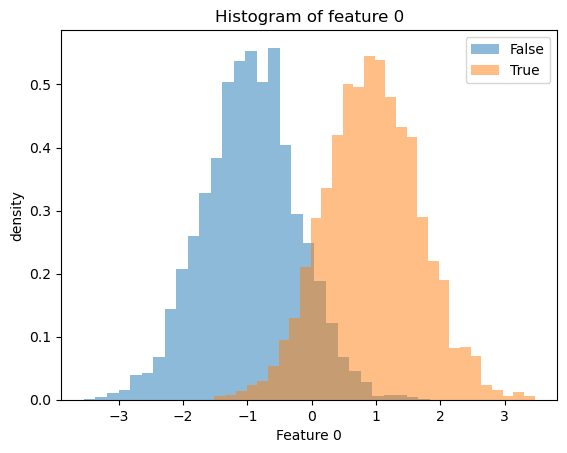

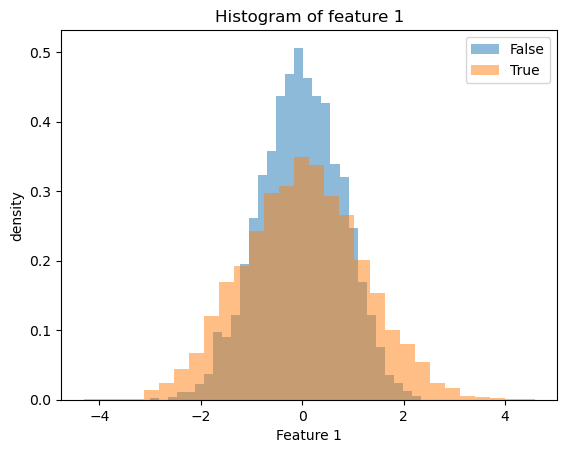

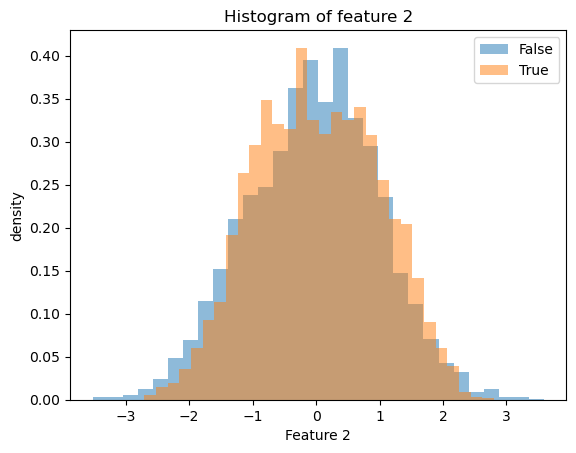

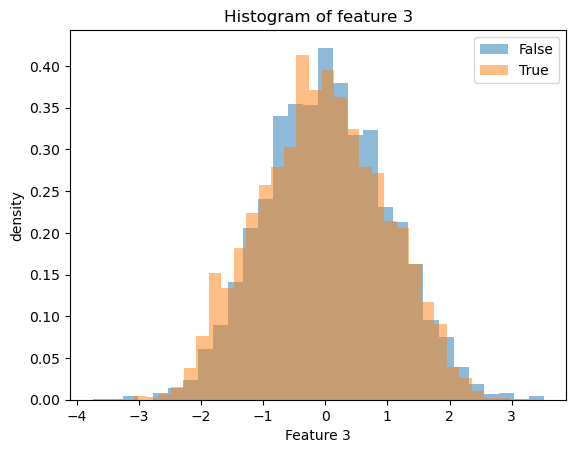

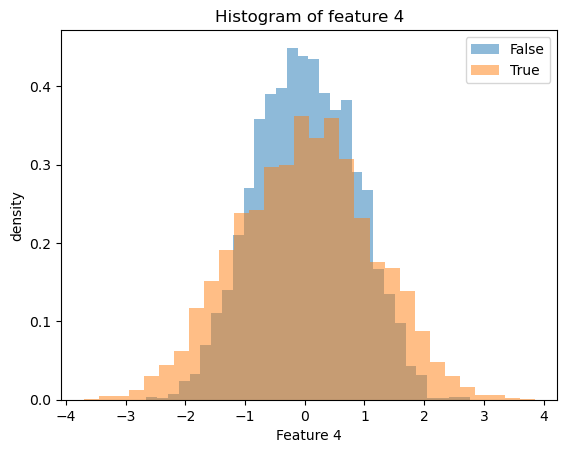

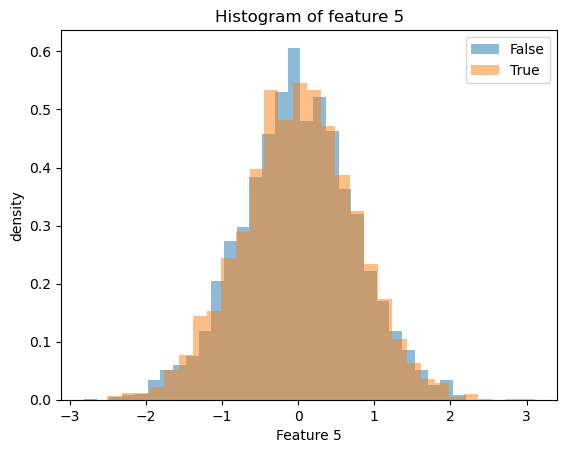

In [105]:
def PCA(x,m):
    C=getC(x)
    s, U = np.linalg.eigh(C)
    P = U[:, ::-1][:, 0:m]
    DP = np.dot(P.T, x)
    return P,DP  # Restituisce P (matrice di proiezione)


U,DP=PCA(D,6)
getHist(DP,L,labels)

In [106]:
# Salva gli istogrammi delle feature PCA
# def savePCAHist(D, L, m, classes):
#     C = getC(D)
#     _, U = np.linalg.eigh(C)
#     P = U[:, ::-1][:, 0:m]
#     DP = np.dot(P.T, D)
#     
#     for i in range(m):
#         plt.figure()
#         plt.ylabel("density")
#         plt.xlabel(f"Feature {i}")
#         for cnt in range(2):
#             mask = L == cnt
#             feature_data = DP[:, mask][i, :]
#             plt.hist(feature_data, bins=30, density=True, alpha=0.5, label=f"{classes[cnt]}")
#         
#         plt.legend()
#         plt.title(f"Histogram of feature {i}")
#         plt.tight_layout()
#         plt.savefig(f'../images/pca_histogram_feature_{i}.png', dpi=150, bbox_inches='tight')
#         plt.close()
#     print(f"Salvati {m} istogrammi PCA")

# savePCAHist(D, L, 6, labels)

## 4. Linear Discriminant Analysis (LDA)

LDA è una tecnica **supervised** che trova la direzione ottimale per separare le classi:

### 4.1 Between-class e Within-class Covariance

La funzione `compute_Sb_Sw()` calcola:
- **$S_B$ (between-class)**: varianza tra le medie delle classi
- **$S_W$ (within-class)**: varianza all'interno di ciascuna classe

LDA massimizza il rapporto di Fisher: $J(\mathbf{w}) = \frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}}$

In [107]:
def compute_Sb_Sw(D,L):
    Sw=0
    Sb=0
    N=D.shape[1]
    mu=vCol(getMu(D))
    # Itera sulle classi uniche presenti nei dati, non su range(len(classes))
    for c in np.unique(L):
        mask=L==c
        D0=D[:,mask]
        nc=D0.shape[1]
        mc=vCol(getMu(D0))
        Sb+=nc*((mc-mu)@(mc-mu).T)
        DC=D0-mc
        Sw+=(DC @ DC.T)
    return Sb/N,Sw/N

Sb,Sw=compute_Sb_Sw(D,L)
print(f"La between class covariance matrix è {Sb} \n La within class covariance matrix è{Sw}")



La between class covariance matrix è [[ 1.36058485e-06  1.58737358e-05 -7.85114318e-04  7.78613509e-04
   4.06398379e-05 -1.73599814e-05]
 [ 1.58737358e-05  1.85196452e-04 -9.15980889e-03  9.08396495e-03
   4.74138784e-04 -2.02536252e-04]
 [-7.85114318e-04 -9.15980889e-03  4.53043771e-01 -4.49292533e-01
  -2.34508848e-02  1.00174347e-02]
 [ 7.78613509e-04  9.08396495e-03 -4.49292533e-01  4.45572355e-01
   2.32567096e-02 -9.93448957e-03]
 [ 4.06398379e-05  4.74138784e-04 -2.34508848e-02  2.32567096e-02
   1.21388712e-03 -5.18532032e-04]
 [-1.73599814e-05 -2.02536252e-04  1.00174347e-02 -9.93448957e-03
  -5.18532032e-04  2.21499565e-04]] 
 La within class covariance matrix è[[ 1.00134167e+00  5.15168444e-03  2.55257807e-03  1.37482622e-02
   9.96603919e-03 -1.29417640e-02]
 [ 5.15168444e-03  9.98167503e-01 -6.67560485e-03 -9.52461523e-03
  -4.48721195e-03 -6.15150847e-04]
 [ 2.55257807e-03 -6.67560485e-03  5.49438024e-01  1.22321515e-02
  -3.40917458e-03 -3.67354969e-03]
 [ 1.37482622e-0

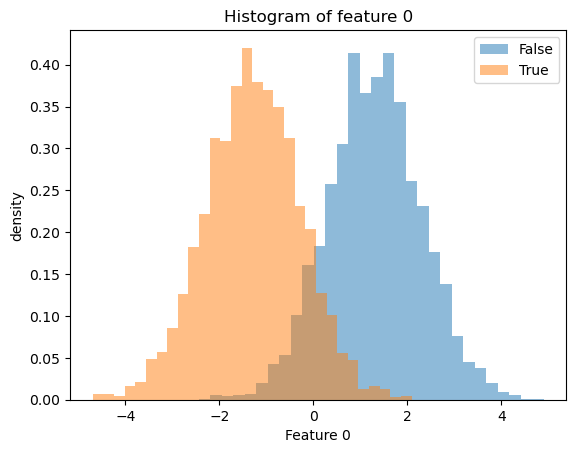

In [108]:
def LDA(D,L,classes,m):
    Sb,Sw=compute_Sb_Sw(D,L)
    s, U = scipy.linalg.eigh(Sb, Sw)
    W = U[:, ::-1][:, 0:m]
    DP=W.T @ D
    return W,DP

W,DP=LDA(D,L,labels,1)
getHist(DP,L,labels)

### 4.2 Proiezione LDA

Con 2 classi, LDA può trovare **al massimo 1 direzione discriminante** (min(n_classes-1, n_features) = 1).

La funzione `LDA()` risolve il problema degli autovalori generalizzato $S_B \mathbf{w} = \lambda S_W \mathbf{w}$ per trovare la direzione ottimale.

**Risultato atteso**: Separazione delle classi migliore rispetto alle singole feature originali.

In [109]:
# Salva istogramma LDA
# def saveLDAHist(D, L, m, classes):
#     Dlda = LDA(D, L, m)
#     plt.figure()
#     plt.ylabel("density")
#     plt.xlabel("LDA Direction")
#     for cnt in range(2):
#         mask = L == cnt
#         feature_data = Dlda[:, mask][0, :]
#         plt.hist(feature_data, bins=30, density=True, alpha=0.5, label=f"{classes[cnt]}")
#     
#     plt.legend()
#     plt.title("Histogram of LDA projection")
#     plt.tight_layout()
#     plt.savefig('../images/lda_histogram.png', dpi=150, bbox_inches='tight')
#     plt.close()
#     print("Salvato istogramma LDA")

# saveLDAHist(D, L, 1, labels)

In [110]:
def split_db_2to1(D, L, seed=0):
    nTrain = int(D.shape[1]*2.0/3.0)
    np.random.seed(seed)
    idx = np.random.permutation(D.shape[1])
    idxTrain = idx[0:nTrain]
    idxTest = idx[nTrain:]
    DTR = D[:, idxTrain]
    DVAL = D[:, idxTest]
    LTR = L[idxTrain]
    LVAL = L[idxTest]
    return (DTR, LTR), (DVAL, LVAL)
# DTR and LTR are model training data and labels
# DVAL and LVAL are validation data and labels
(DTR, LTR), (DVAL, LVAL) = split_db_2to1(D, L)

## 5. Classificazione con LDA

### 5.1 Split Train/Validation

Per valutare le performance del modello, dividiamo il dataset in:
- **Training set**: 2/3 dei campioni (usato per stimare i parametri del modello)
- **Validation set**: 1/3 dei campioni (usato per valutare le performance)

Questo evita overfitting e simula uno scenario applicativo reale.

In [111]:
def classify_with_LDA(DTR,LTR,DVAL,LVAL):
    
    unique_classes = np.unique(LTR)
    # Calcola LDA SOLO sul training set
    W,DTR_lda = LDA(DTR,LTR,unique_classes,1)

    # Controlla l'orientamento: la media di True (1) deve essere > media di False (0)
    DTR_lda = W.T @ DTR
    mean_false = DTR_lda[0, LTR==0].mean()
    mean_true = DTR_lda[0, LTR==1].mean()

    # Se l'orientamento è sbagliato, inverti W
    if mean_true < mean_false:
        W = -W
        DTR_lda = W.T @ DTR
        mean_false = DTR_lda[0, LTR==0].mean()
        mean_true = DTR_lda[0, LTR==1].mean()

    # Applica la stessa trasformazione W ai dati di validazione
    DVAL_lda = W.T @ DVAL

    # Calcola threshold come media delle medie di classe
    threshold = (mean_false + mean_true) / 2.0

    # Predizioni
    PVAL = np.zeros(shape=LVAL.shape, dtype=np.int32)
    PVAL[DVAL_lda[0] >= threshold] = 1
    PVAL[DVAL_lda[0] < threshold] = 0

    print('Threshold:', threshold)
    print('Mean False:', mean_false, 'Mean True:', mean_true)
    print('Labels:     ', LVAL)
    print('Predictions:', PVAL)
    print('Number of errors:', (PVAL != LVAL).sum(), '(out of %d samples)' % (LVAL.size))
    print('Error rate: %.1f%%' % ( (PVAL != LVAL).sum() / float(LVAL.size) *100 ))

classify_with_LDA(DTR,LTR,DVAL,LVAL)


Threshold: -0.018534376786207174
Mean False: -1.2975902799385062 Mean True: 1.2605215263660918
Labels:      [0. 0. 1. ... 0. 0. 0.]
Predictions: [0 0 1 ... 0 0 0]
Number of errors: 186 (out of 2000 samples)
Error rate: 9.3%


### 5.2 Classificatore LDA

Il classificatore LDA implementa i seguenti step:
1. **Training**: Calcola LDA sui dati di training (DTR, LTR)
2. **Orientamento**: Verifica che mean_true > mean_false (convenzione per classificazione)
3. **Proiezione validation**: Applica la stessa trasformazione W ai dati di validazione
4. **Threshold**: Usa la media delle medie proiettate delle classi
5. **Classificazione**: Campioni >= threshold → True (1), altrimenti False (0)

**Performance attese**: ~90% di accuratezza sul validation set.

## Perché controllare l'orientamento di W?

LDA restituisce un autovettore con **segno arbitrario**: la direzione può essere invertita casualmente.

### Il problema

La classificazione binaria usa una regola fissa:
- `>= threshold` → **True (1)**
- `< threshold` → **False (0)**

Se il segno di `W` è "sbagliato", le classi si trovano invertite nello spazio proiettato:

```python
# Caso sfortunato: W ha segno sbagliato
# mean_false = 2, mean_true = -2
threshold = 0
PVAL[DVAL_lda[0] >= 0] = 1  # Classificherebbe False come True! ❌
```

### La soluzione

Forzare la convenzione **"True a destra"** (`mean_true > mean_false`):

```python
# Se l'orientamento è sbagliato, inverti W
if mean_true < mean_false:
    W = -W
# Ora: mean_false = -2, mean_true = 2
threshold = 0
PVAL[DVAL_lda[0] >= 0] = 1  # Funziona correttamente! ✅
```

### Perché è necessario solo nella classificazione binaria?

| Situazione | Problema |
|---|---|
| Autovettore segno casuale | `mean_true` può essere < `mean_false` |
| Threshold fisso | La regola `>=` dipende dalla posizione relativa delle classi |
| Senza controllo | Classificazione completamente invertita |
| **Con controllo** | **Convenzione garantita indipendentemente dal segno** |

> **Nota:** Questo non cambia la qualità della separazione tra classi, ma garantisce solo che la **convenzione di classificazione** sia consistente.

In [112]:
def classify_with_PCA_and_LDA(D, L, m):
    (DTR, LTR), (DVAL, LVAL) = split_db_2to1(D, L)
    
    # PCA sul training set
    P, DTR_pca = PCA(DTR, m)
    DVAL_pca = P.T @ DVAL
    
    
    # Applica la stessa proiezione PCA ai dati di validazione
    DVAL_pca = P.T @ DVAL  
    
    # LDA sul training set PCA-preprocessato
    Sb_tr, Sw_tr = compute_Sb_Sw(DTR_pca, LTR)
    s, U = scipy.linalg.eigh(Sb_tr, Sw_tr)
    W = U[:, ::-1][:, 0:1]
    
    # Controlla orientamento
    DTR_lda = W.T @ DTR_pca
    mean_false = DTR_lda[0, LTR==0].mean()
    mean_true = DTR_lda[0, LTR==1].mean()
    
    if mean_true < mean_false:
        W = -W
        DTR_lda = W.T @ DTR_pca
        mean_false = DTR_lda[0, LTR==0].mean()
        mean_true = DTR_lda[0, LTR==1].mean()
    
    # Applica LDA ai dati di validazione PCA-preprocessati
    DVAL_lda = W.T @ DVAL_pca  
    
    # Threshold e classificazione
    threshold = (mean_false + mean_true) / 2.0
    PVAL = np.zeros(shape=LVAL.shape, dtype=np.int32)
    PVAL[DVAL_lda[0] >= threshold] = 1
    PVAL[DVAL_lda[0] < threshold] = 0
    
    error_rate = (PVAL != LVAL).sum() / float(LVAL.size) * 100
    return error_rate

# Analizza le prestazioni in funzione di m
print("Analisi PCA + LDA: Error rate vs numero di dimensioni PCA\n")
for m in range(1, 7):
    error_rate = classify_with_PCA_and_LDA(D, L, m)
    print(f"m = {m}: Error rate = {error_rate:.1f}%")

Analisi PCA + LDA: Error rate vs numero di dimensioni PCA

m = 1: Error rate = 9.3%
m = 2: Error rate = 9.2%
m = 3: Error rate = 9.2%
m = 4: Error rate = 9.2%
m = 5: Error rate = 9.3%
m = 6: Error rate = 9.3%


## 6. Pre-processing con PCA + Classificazione LDA

### Pipeline completa:
```
DTR → PCA(m dimensions) → DTR_pca → LDA(1 direction) → DTR_lda → Classification
DVAL → PCA(same P) → DVAL_pca → LDA(same W) → DVAL_lda → Predictions
```

**Obiettivo**: Analizzare se il preprocessing con PCA migliora le performance di classificazione LDA.

**Nota critica**: Sia PCA che LDA devono essere stimati **solo sui dati di training**, poi applicati ai dati di validazione con le stesse matrici P e W.

Testiamo diversi valori di m (dimensioni PCA) da 1 a 6 per trovare il valore ottimale.